# IMDb Sentiment Classification Final Results

This notebook presents the final results for the IMDb sentiment classification project.

The goal of this project is to compare traditional machine learning models, a lightweight neural network, and a pretrained transformer model for binary sentiment classification.

The models compared are:

1. TF-IDF + Logistic Regression
2. TF-IDF + Naive Bayes
3. Lightweight CNN
4. DistilBERT

## Experimental Setup

All models were trained and evaluated using the same IMDb subset.

| Split | Number of Examples |
|---|---:|
| Training | 2,000 |
| Validation | 500 |
| Test | 1,000 |

The dataset was shuffled with a fixed random seed before subsetting. This makes the comparison fair because each model uses the same training, validation, and test data.

In [26]:
import pandas as pd
from IPython.display import Image, display

## Main Model Comparison

The table and figures below show the final test performance of all models on the same 1,000-example test subset.

,model,split,accuracy,macro_f1,true_negative,false_positive,false_negative,true_positive,model_display
0,Logistic Regression,test,0.821,0.820991,414,98,81,407,Logistic Regression
1,Naive Bayes,test,0.818,0.816943,447,65,117,371,Naive Bayes
2,CNN,test,0.721,0.720530,340,172,107,381,Lightweight CNN
3,DistilBERT,test,0.834,0.833976,423,89,77,411,DistilBERT


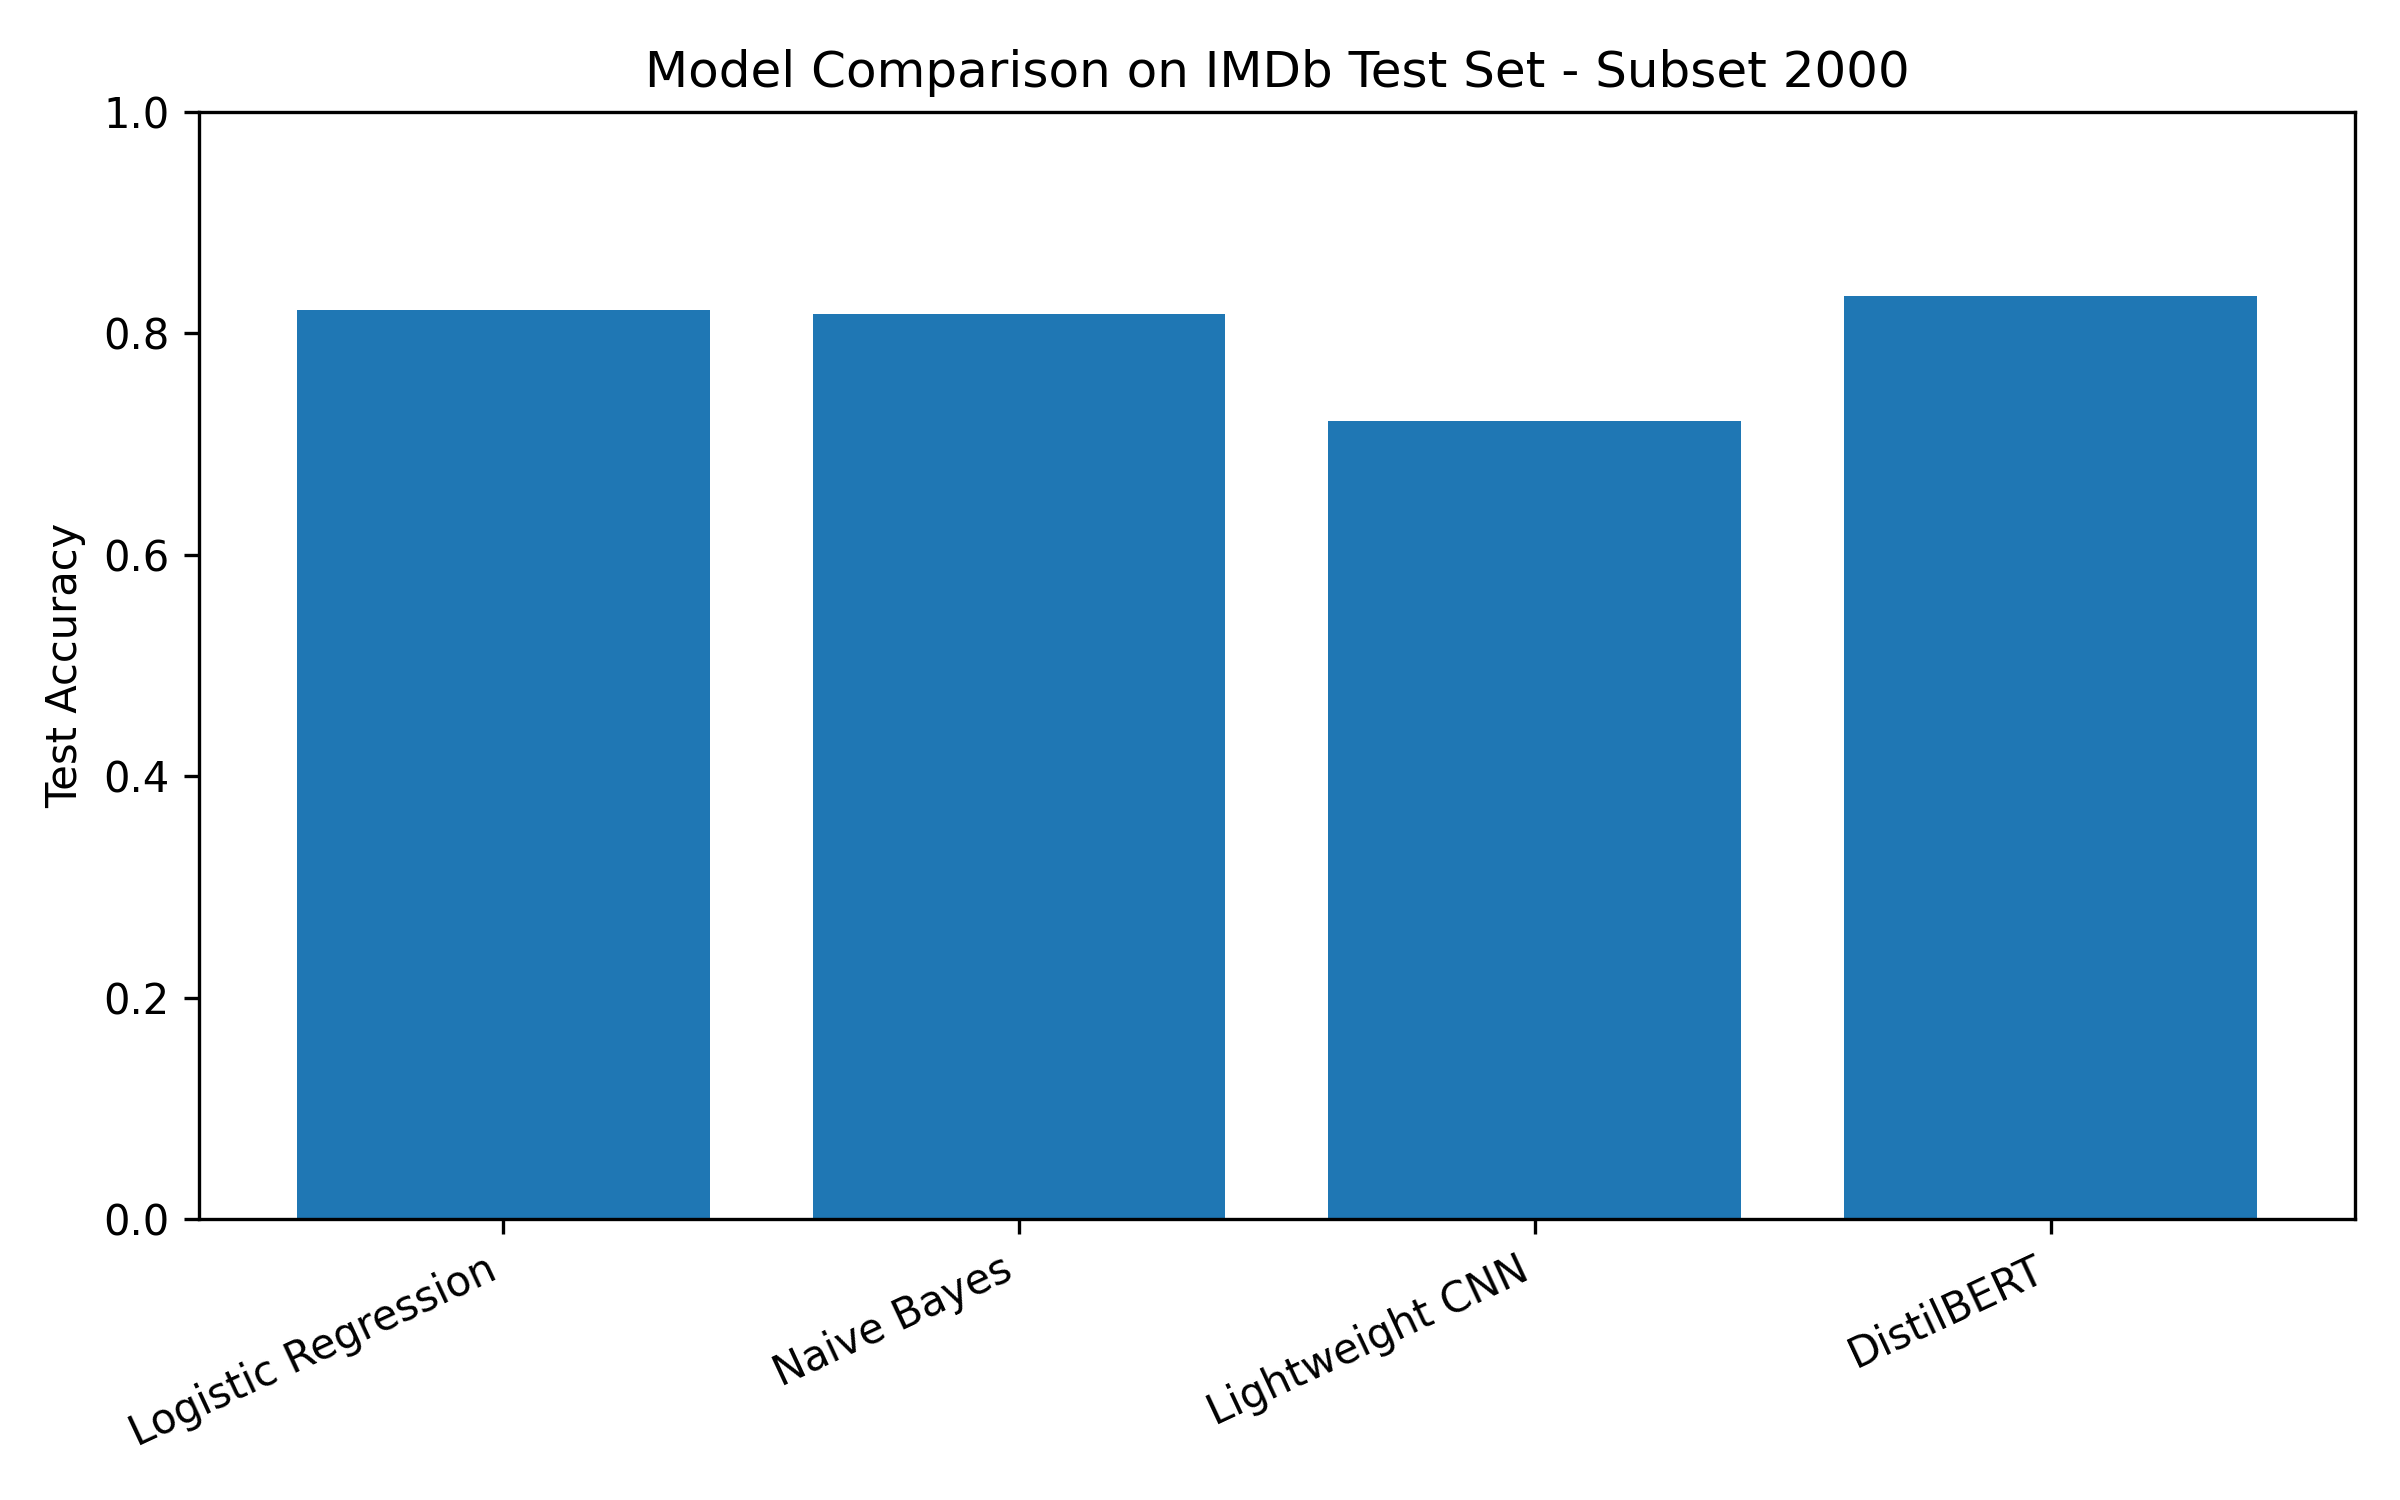

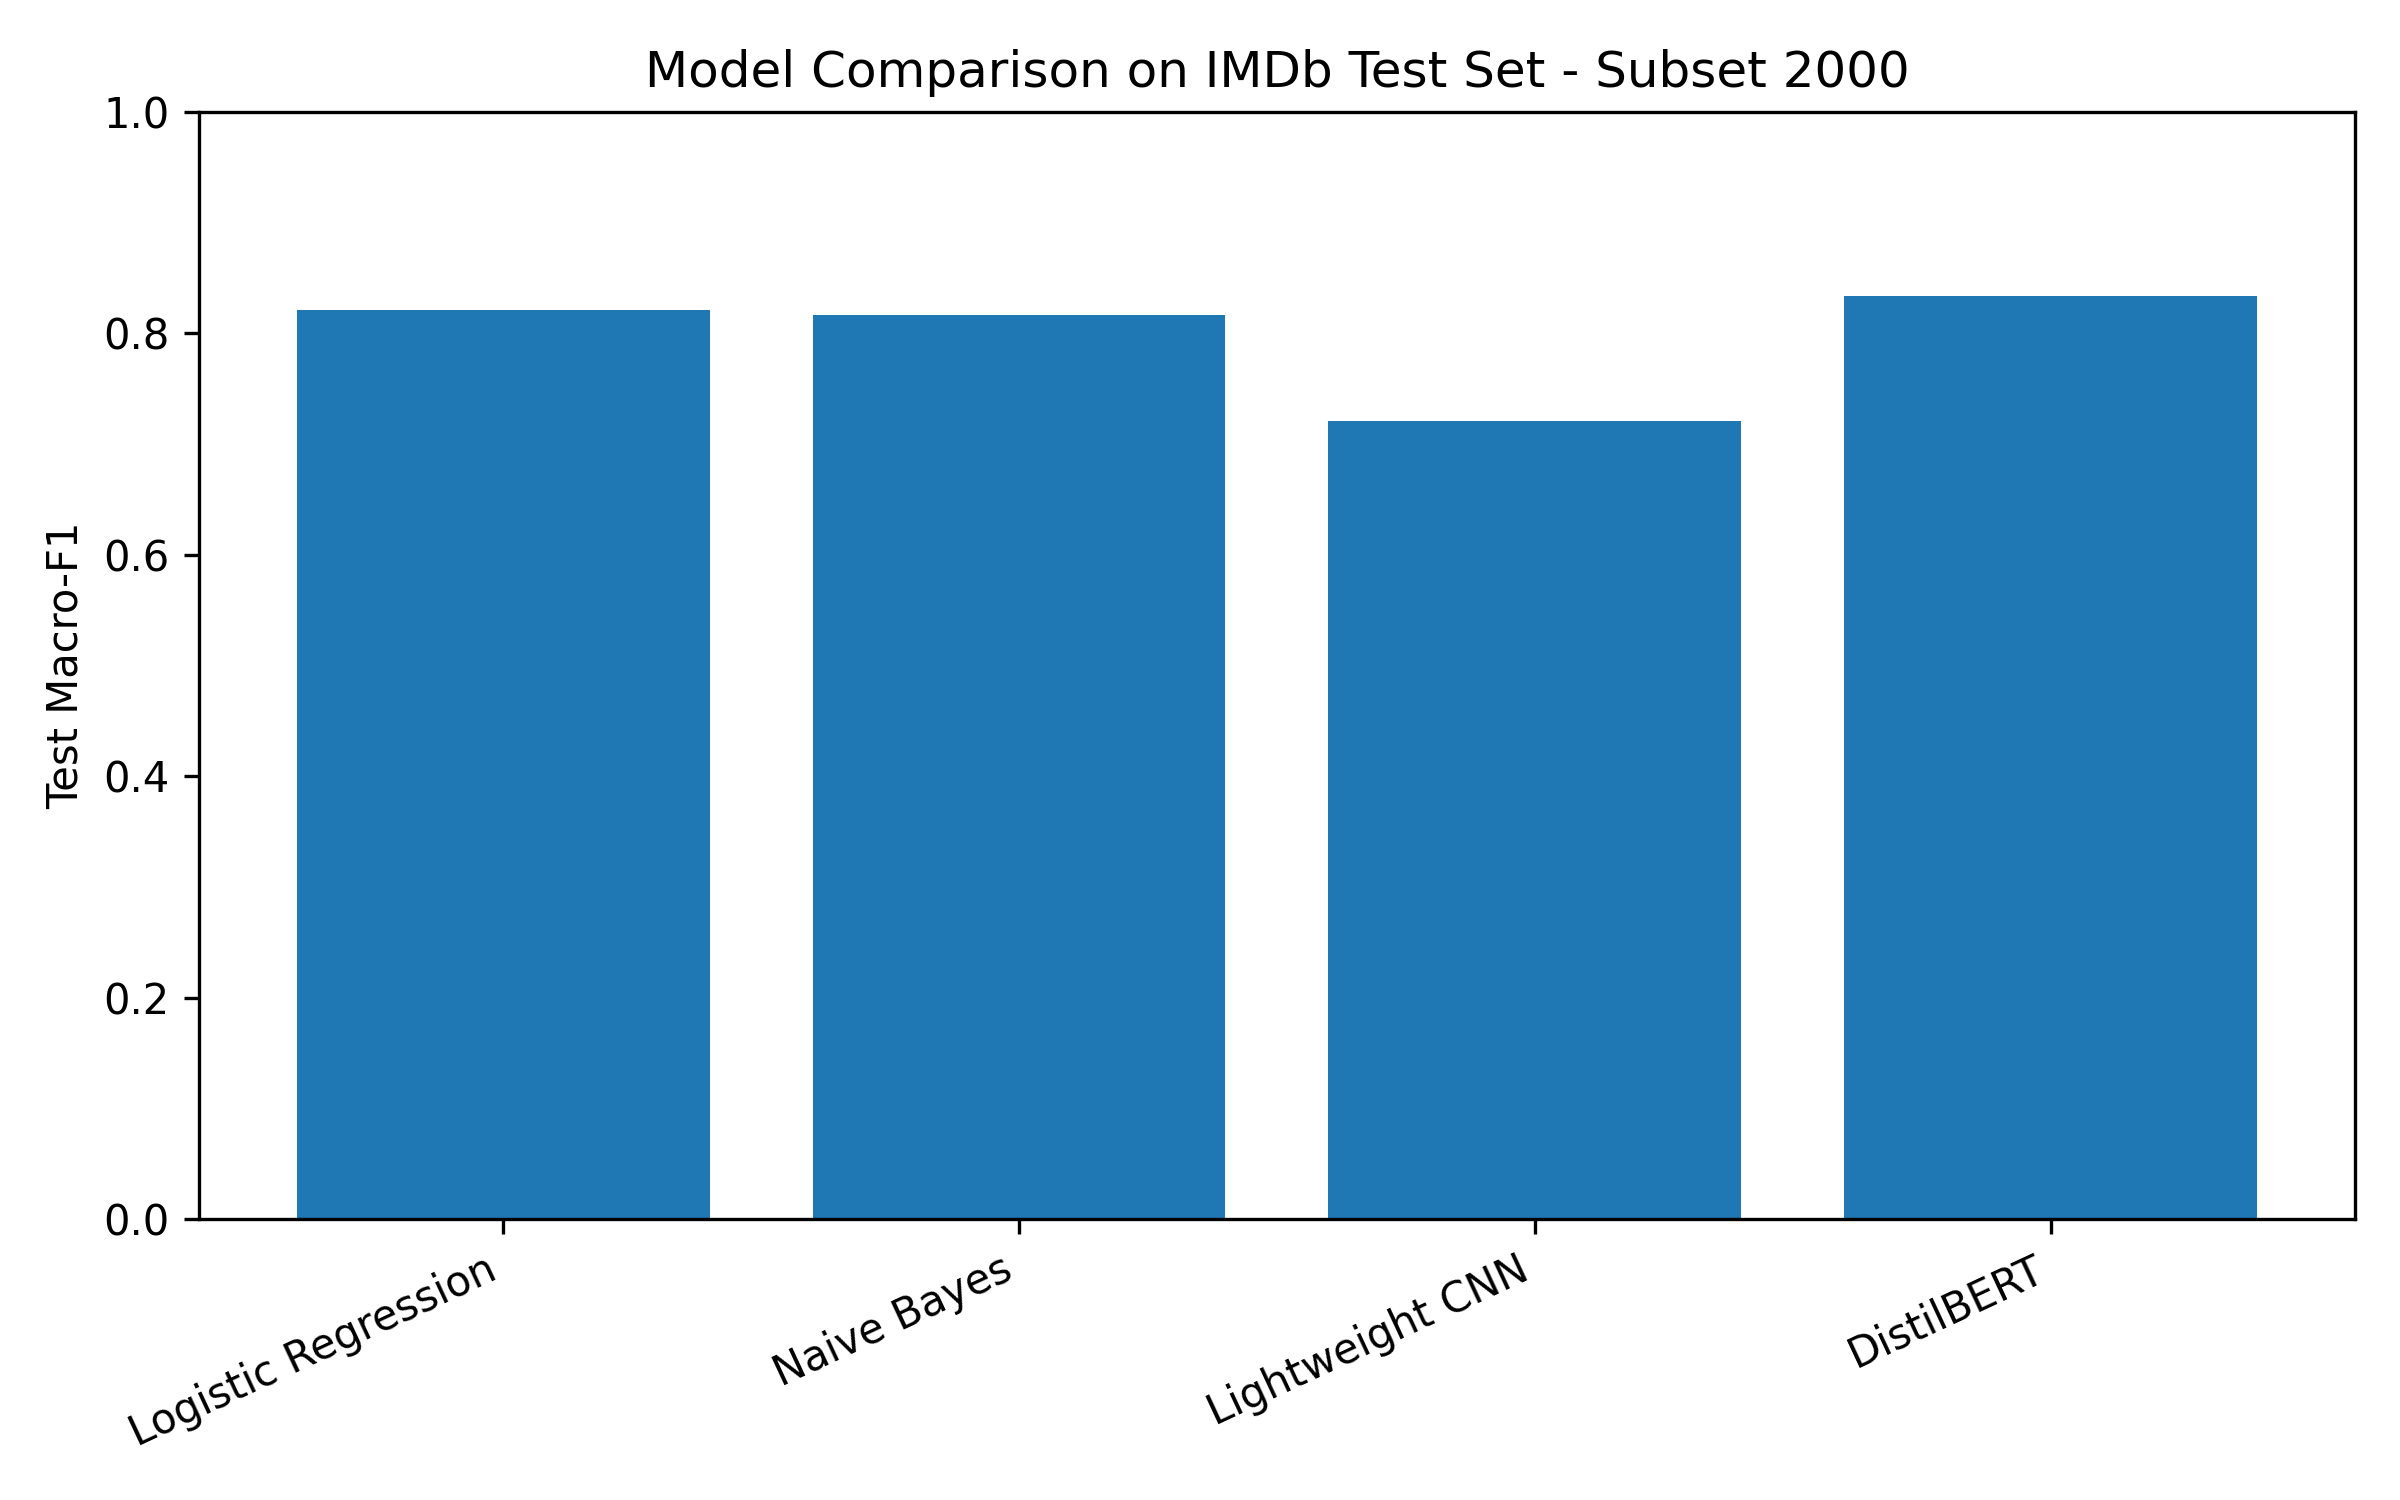

In [27]:
model_results = pd.read_csv("../Results/model_comparison_results_subset_2000.csv")
display(model_results)

display(Image("../figures/model_comparison_accuracy_subset_2000.png"))
display(Image("../figures/model_comparison_macro_f1_subset_2000.png"))

## Main Result Analysis

DistilBERT achieved the best overall test performance, with the highest accuracy and macro-F1 score. This is reasonable because DistilBERT is a pretrained language model and already has useful language representations before fine-tuning.

Logistic Regression and Naive Bayes also performed well. This shows that TF-IDF based models are strong baselines for IMDb sentiment classification because many sentiment labels are strongly related to specific words or phrases.

The Lightweight CNN performed lower than the other models. This is likely because it was trained from scratch using only 2,000 training examples, while DistilBERT benefits from pretraining and the TF-IDF models work well with small text datasets.

## Confusion Matrix Results

The confusion matrices show the number of correct and incorrect predictions for each model. The rows are the true labels and the columns are the predicted labels.

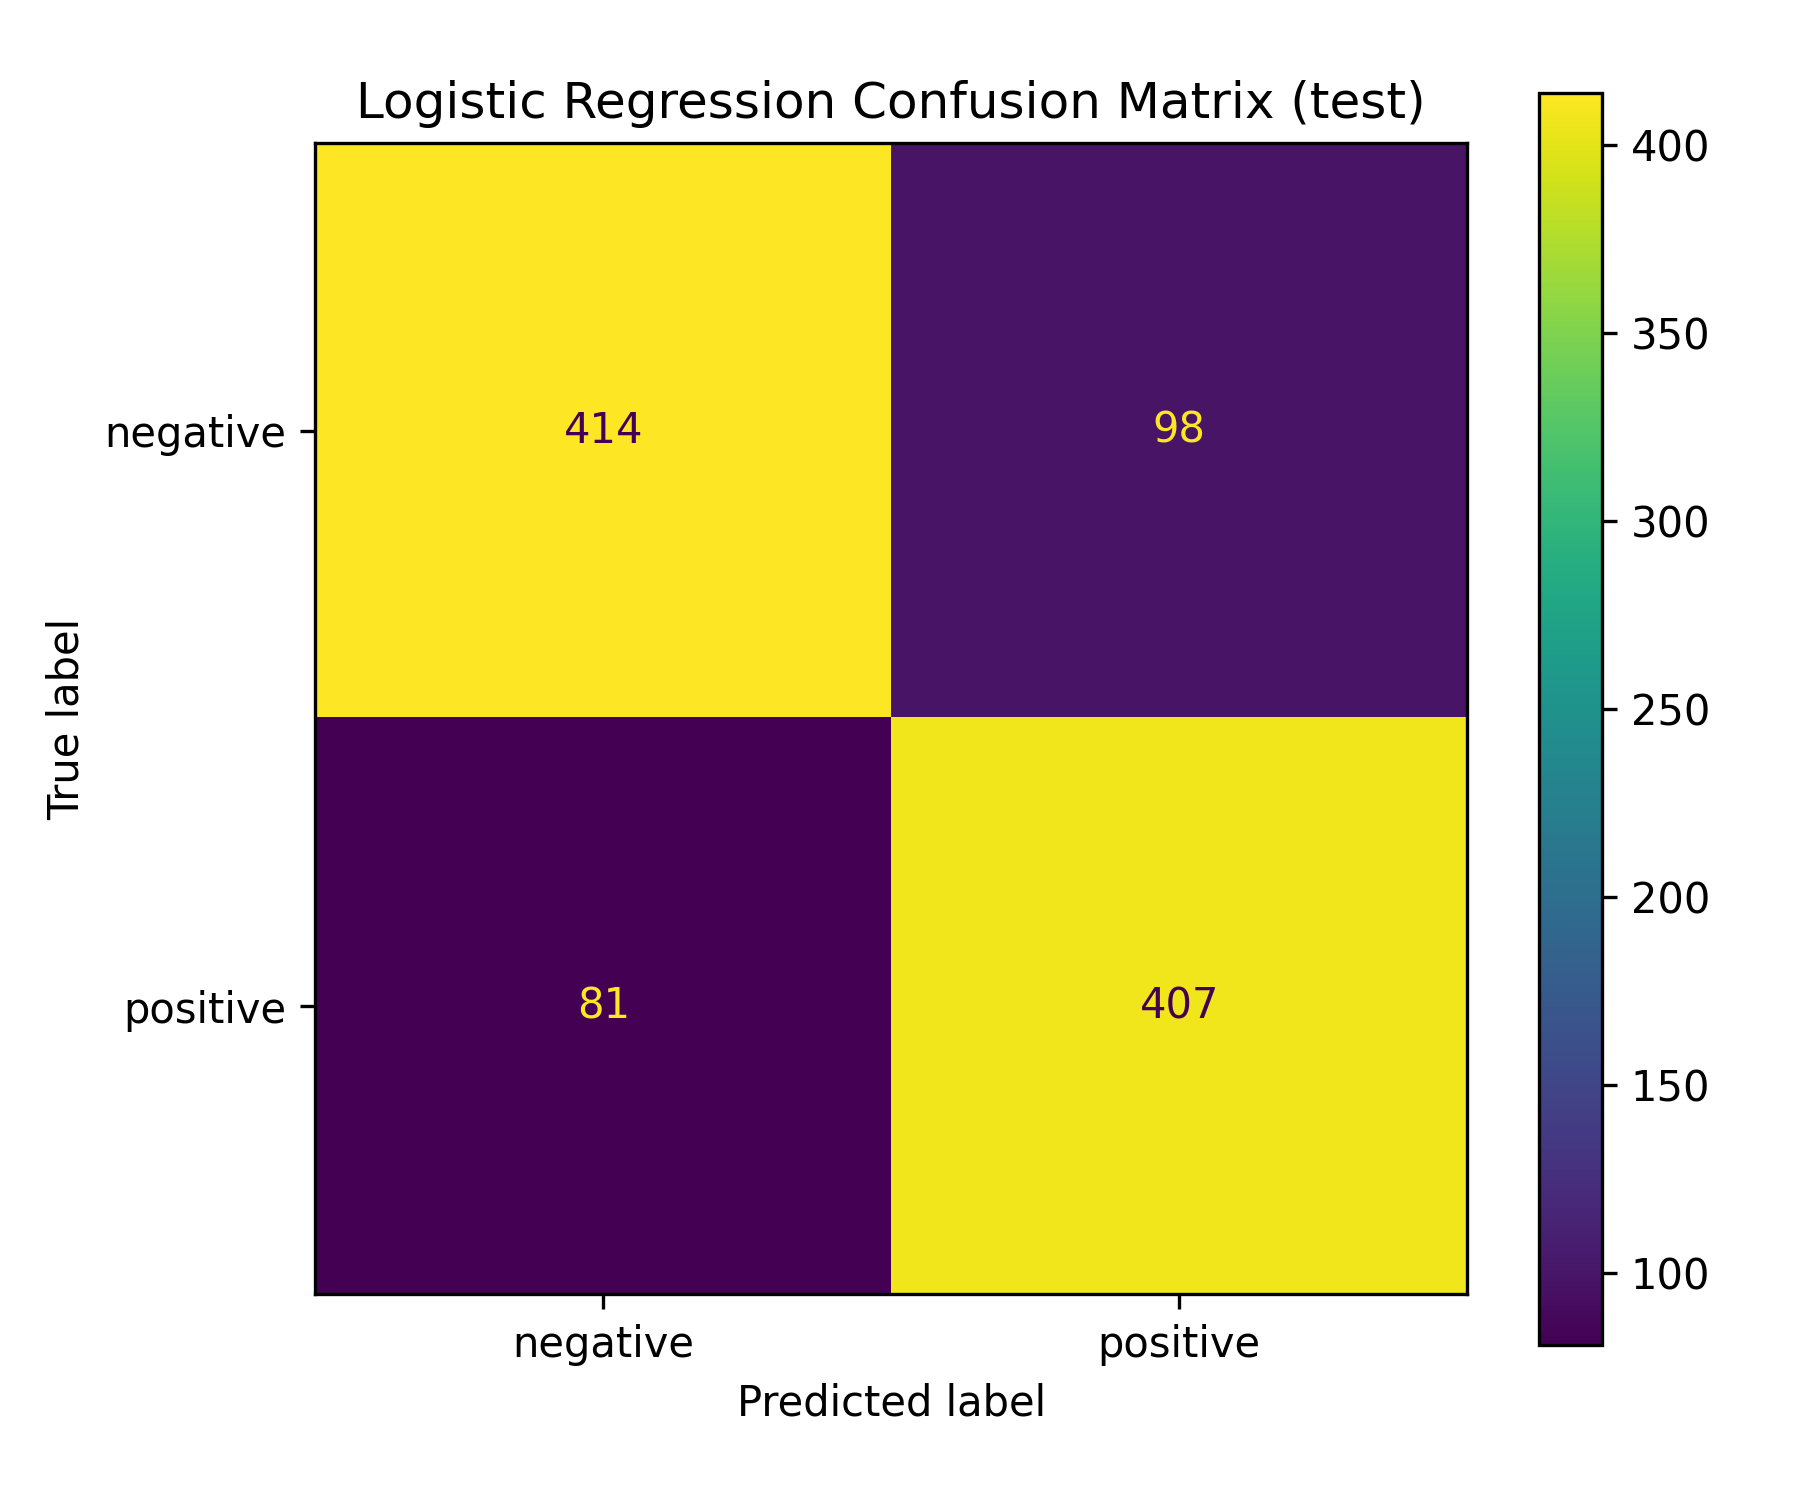

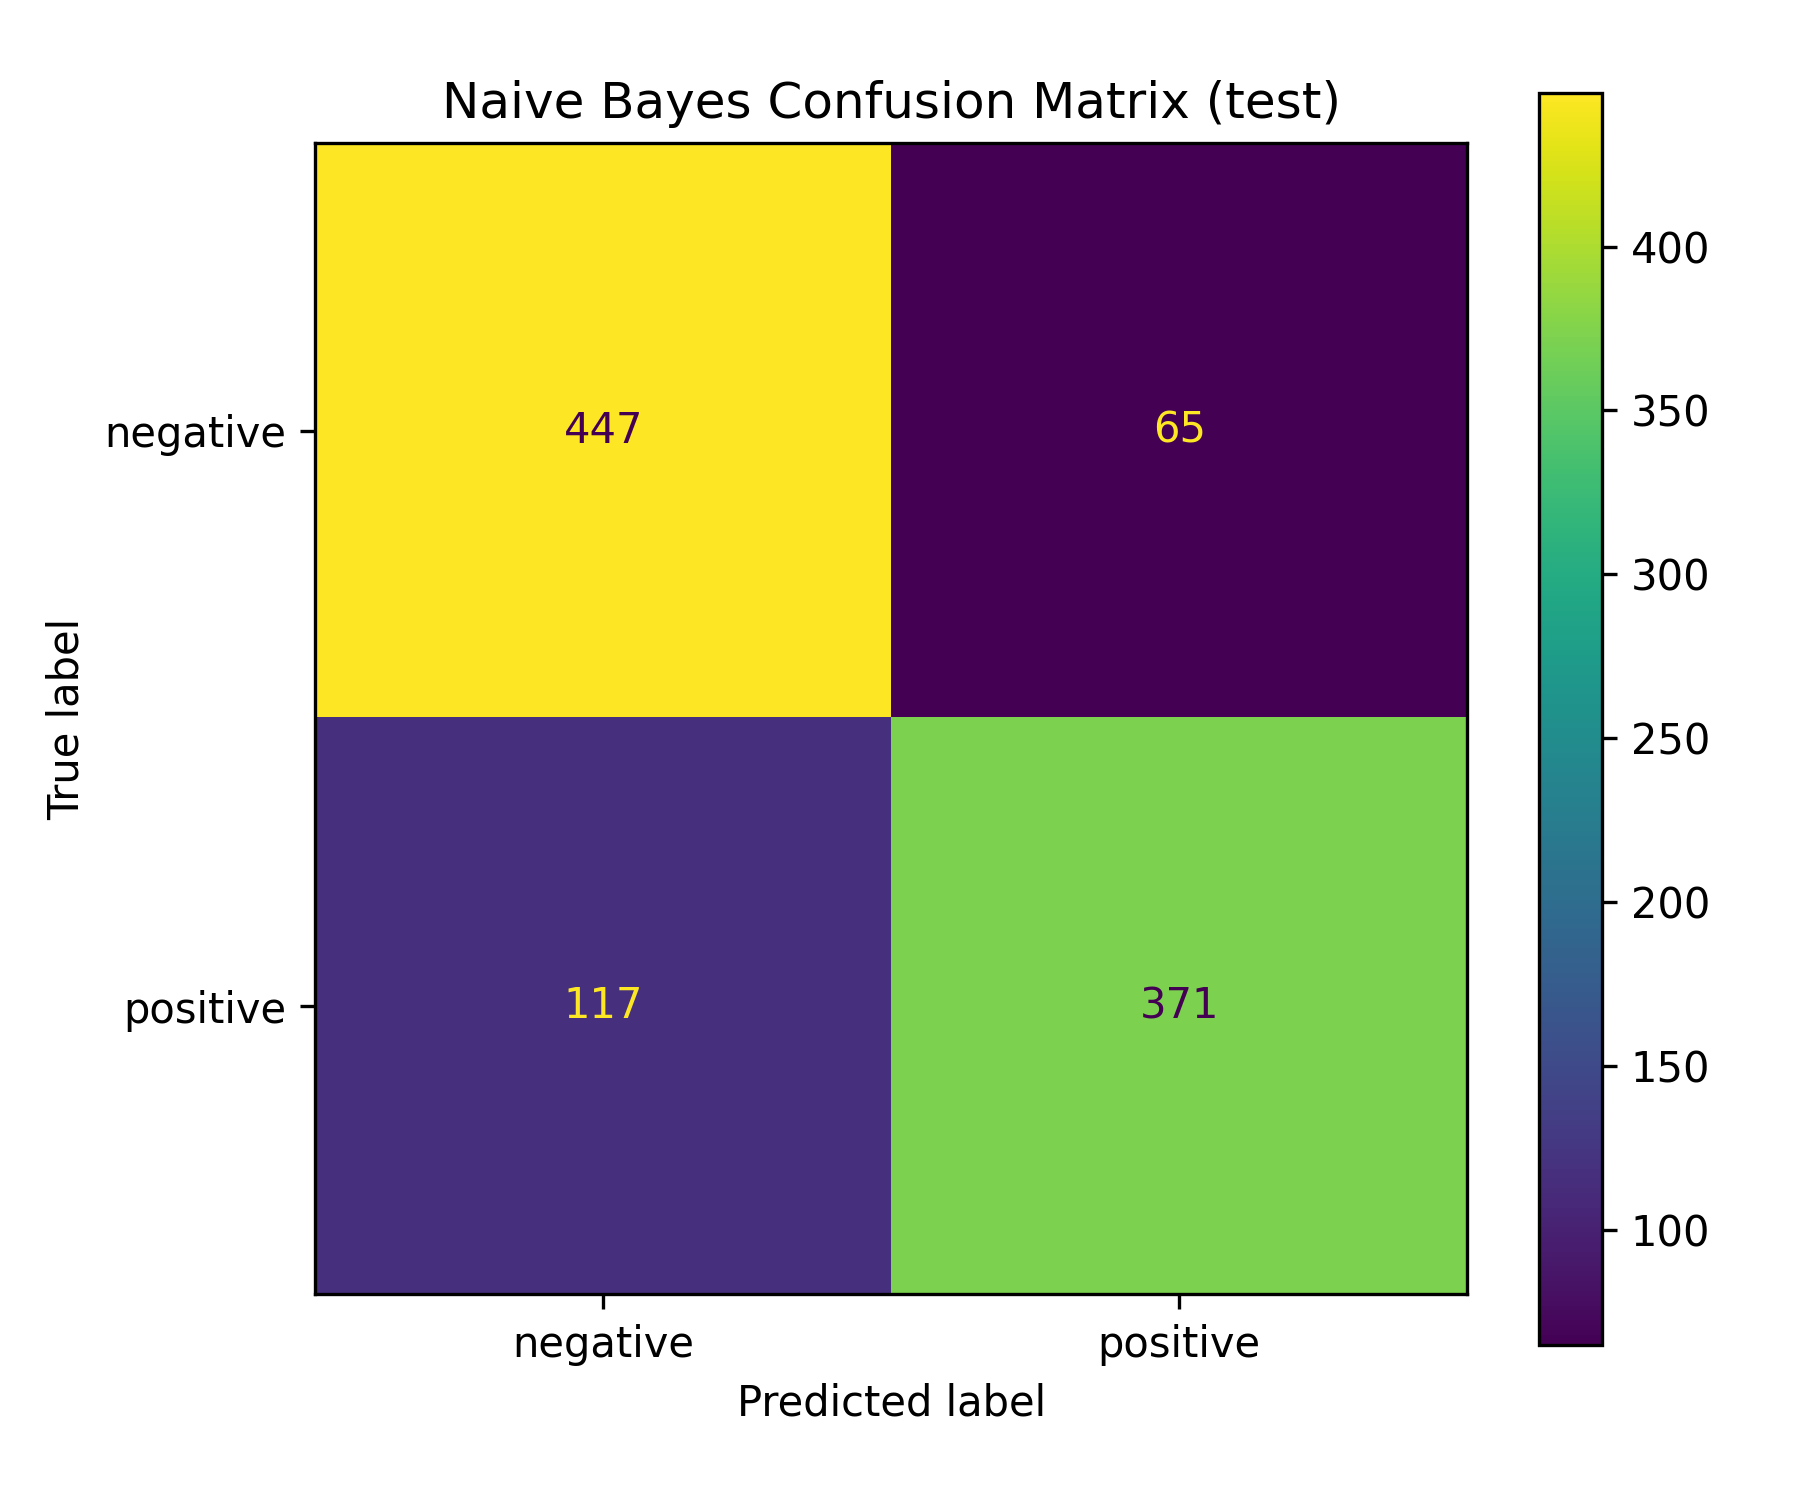

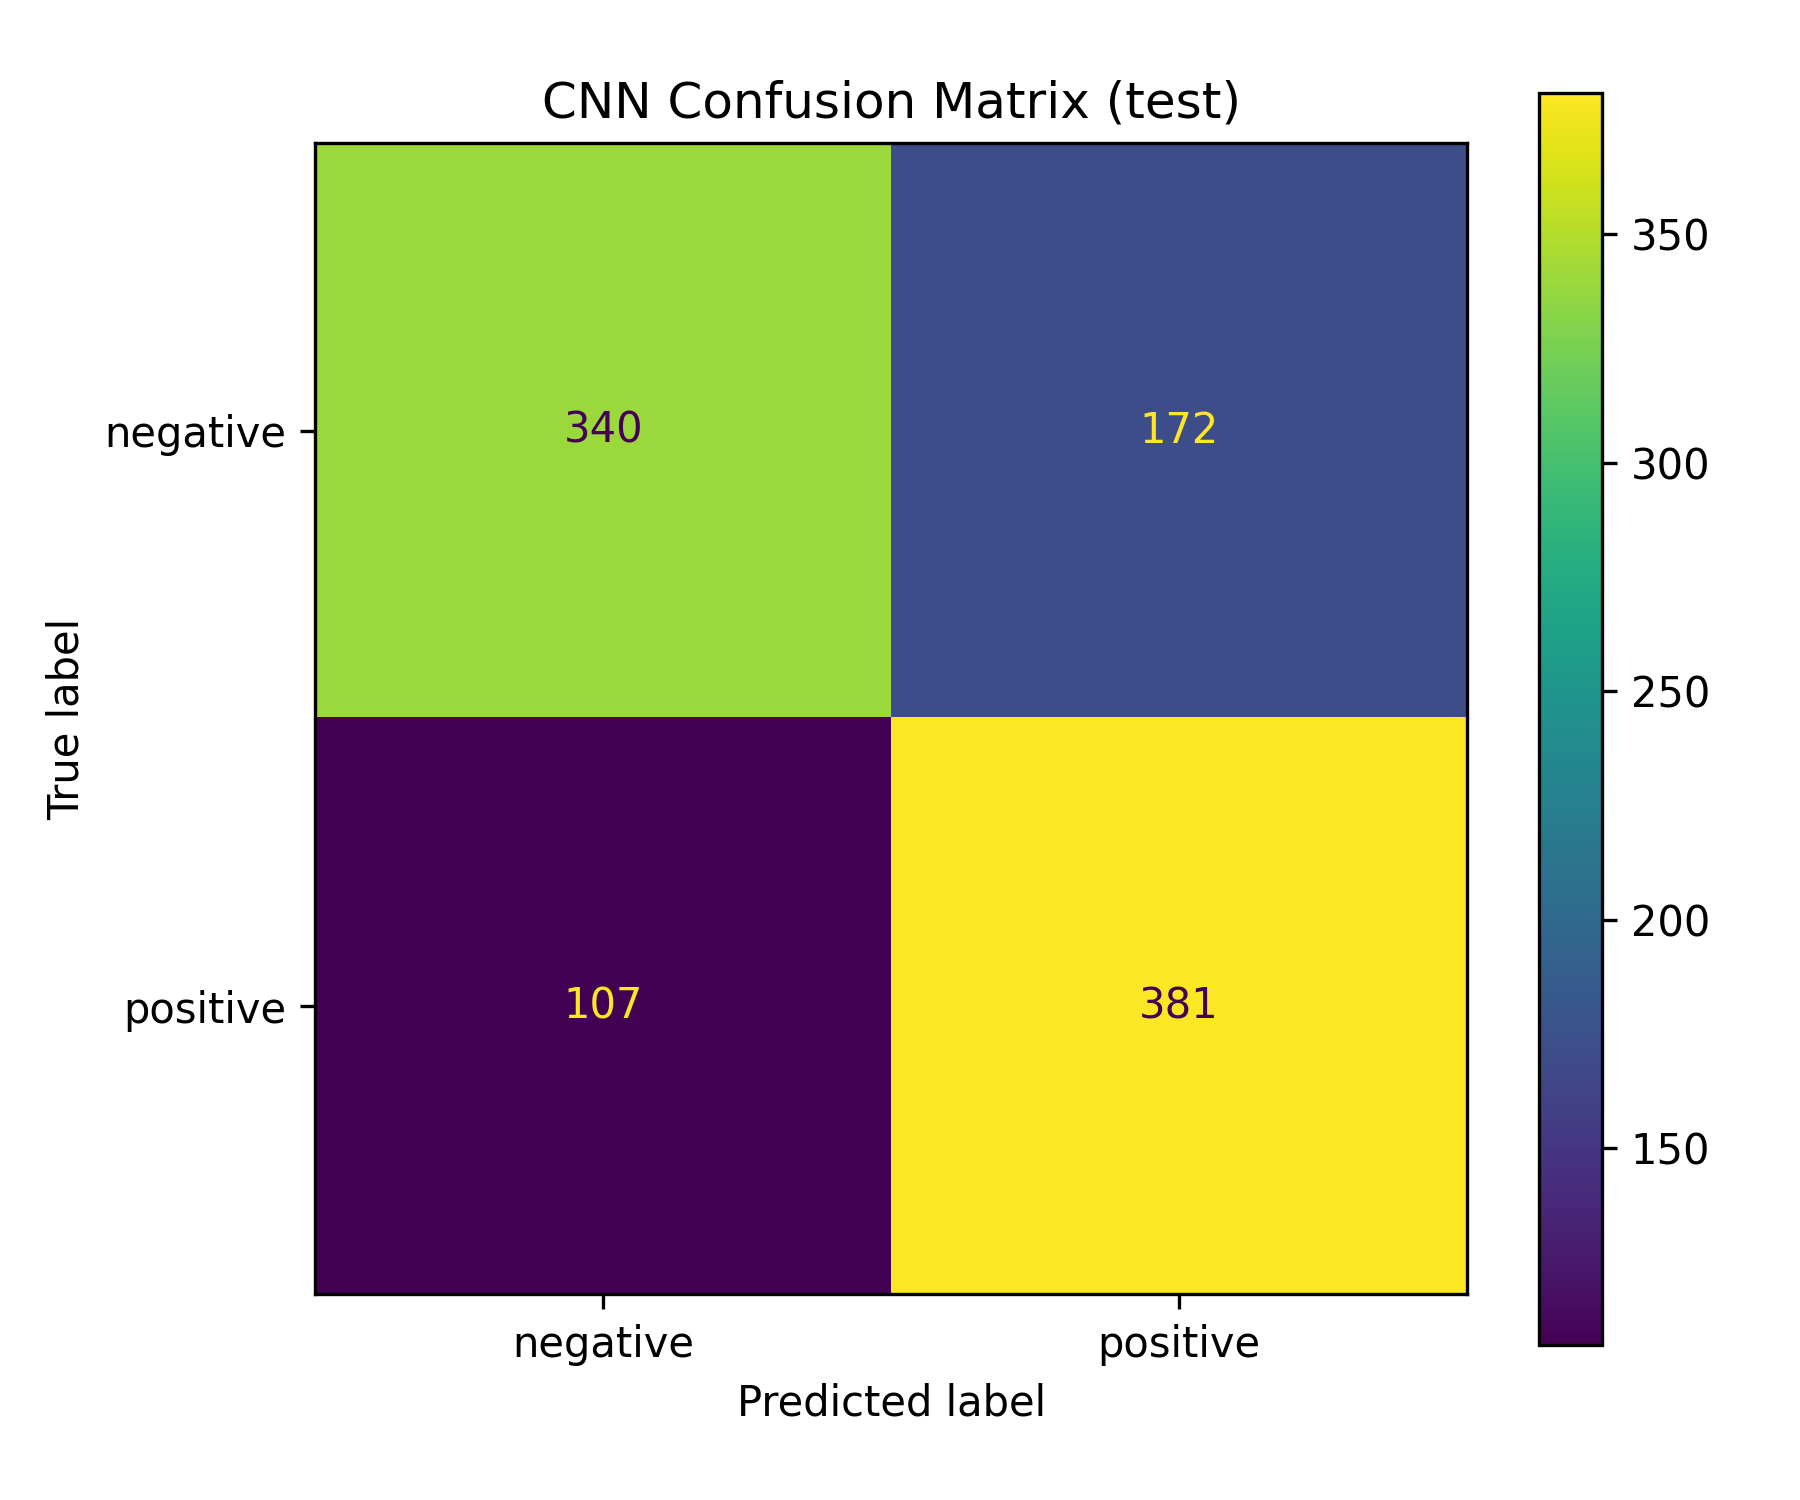

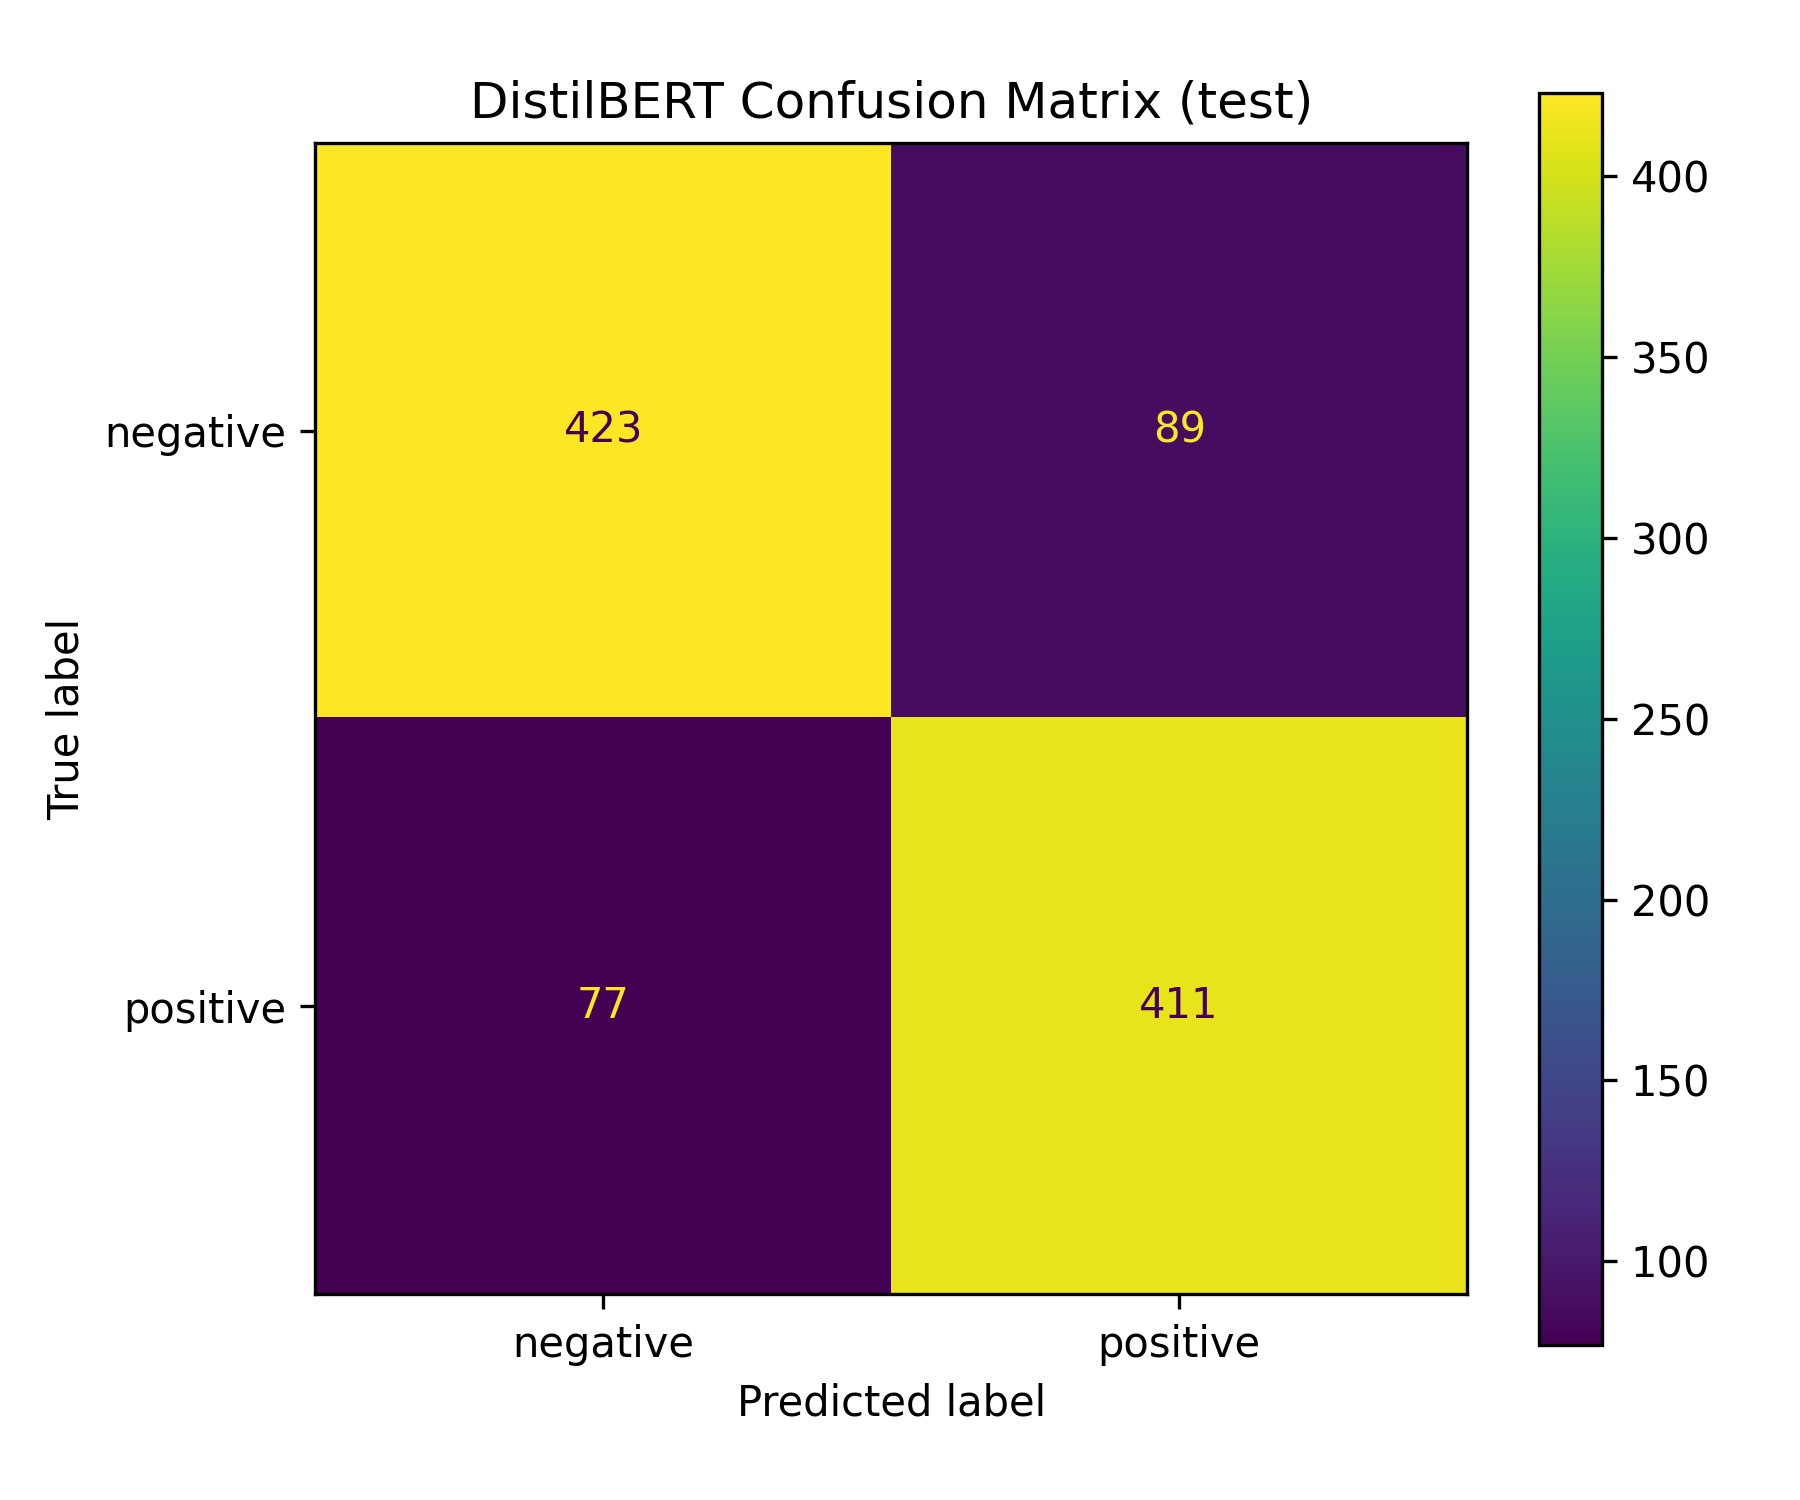

In [28]:
display(Image("../figures/baseline_confusion_matrix_logistic_regression_subset_2000_test.png"))
display(Image("../figures/baseline_confusion_matrix_naive_bayes_subset_2000_test.png"))
display(Image("../figures/cnn_confusion_matrix_subset_2000_test.png"))
display(Image("../figures/bert_confusion_matrix_distilbert_fine_tuned_subset_2000_test.png"))

## Confusion Matrix Analysis

DistilBERT had the strongest overall balance between negative and positive predictions. Logistic Regression also performed well and had similar behavior.

Naive Bayes produced fewer false positives than Logistic Regression, but it produced more false negatives. This means Naive Bayes was more conservative when predicting positive reviews.

The CNN produced more false positives than the other models, which contributed to its lower overall performance.

## Review Length Slice Analysis

This section compares model accuracy across different review length groups.

,model,slice_type,slice_name,num_examples,accuracy
0,Logistic Regression,review_length,short_0_100,132,0.818182
1,Logistic Regression,review_length,medium_101_250,600,0.806667
2,Logistic Regression,review_length,long_251_500,204,0.862745
3,Logistic Regression,review_length,very_long_500_plus,64,0.828125
4,Naive Bayes,review_length,short_0_100,132,0.818182
5,Naive Bayes,review_length,medium_101_250,600,0.808333
6,Naive Bayes,review_length,long_251_500,204,0.848039
7,Naive Bayes,review_length,very_long_500_plus,64,0.812500
8,Lightweight CNN,review_length,short_0_100,132,0.734848
9,Lightweight CNN,review_length,medium_101_250,600,0.723333


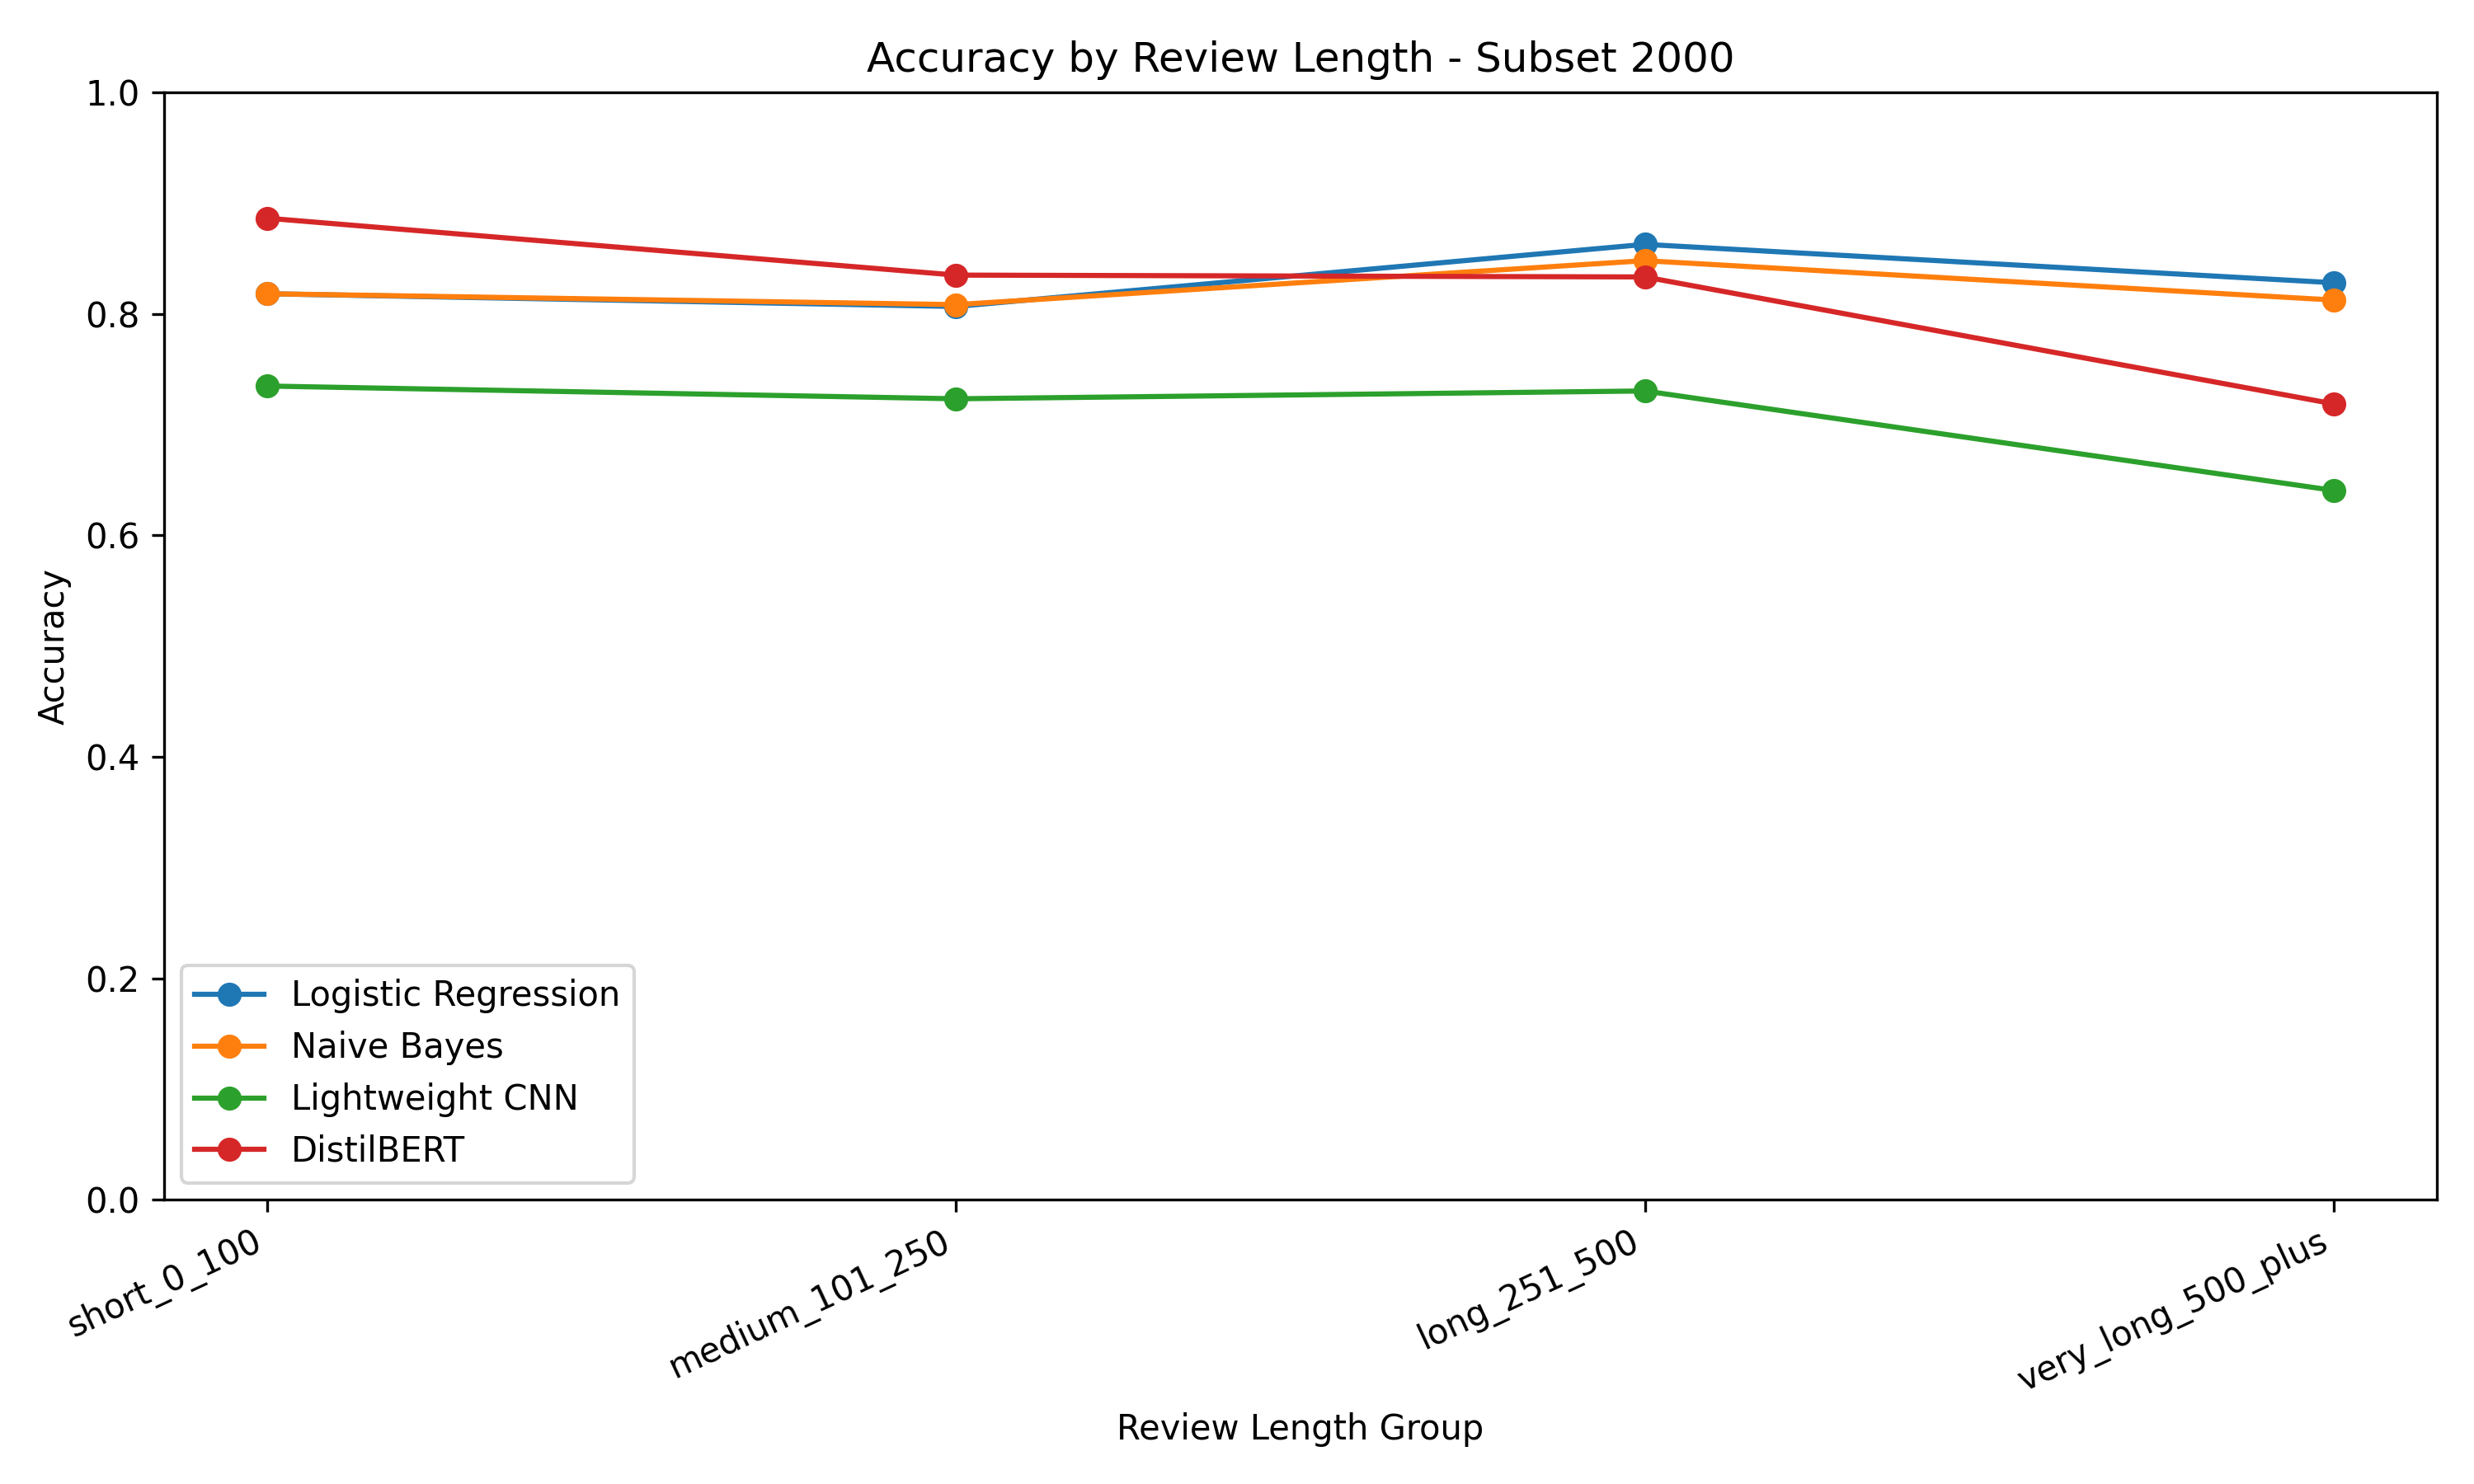

In [29]:
length_results = pd.read_csv("../Results/length_slice_results_subset_2000.csv")
display(length_results)

display(Image("../figures/length_slice_accuracy_subset_2000.png"))

## Review Length Analysis

DistilBERT performed especially well on short reviews. Logistic Regression and Naive Bayes were stable across most length groups. The CNN had the lowest performance, especially on very long reviews.

The drop on very long reviews is reasonable because long reviews may contain mixed opinions or more complex sentiment. Also, transformer models such as DistilBERT use a maximum input length, so very long reviews may be truncated.

## Negation Slice Analysis

This section compares model accuracy on reviews with and without negation words such as "not", "never", "don't", and "isn't".

,model,slice_type,slice_name,num_examples,accuracy
0,Logistic Regression,negation,no_negation,118,0.889831
1,Logistic Regression,negation,contains_negation,882,0.811791
2,Naive Bayes,negation,no_negation,118,0.872881
3,Naive Bayes,negation,contains_negation,882,0.810658
4,Lightweight CNN,negation,no_negation,118,0.771186
5,Lightweight CNN,negation,contains_negation,882,0.714286
6,DistilBERT,negation,no_negation,118,0.889831
7,DistilBERT,negation,contains_negation,882,0.826531


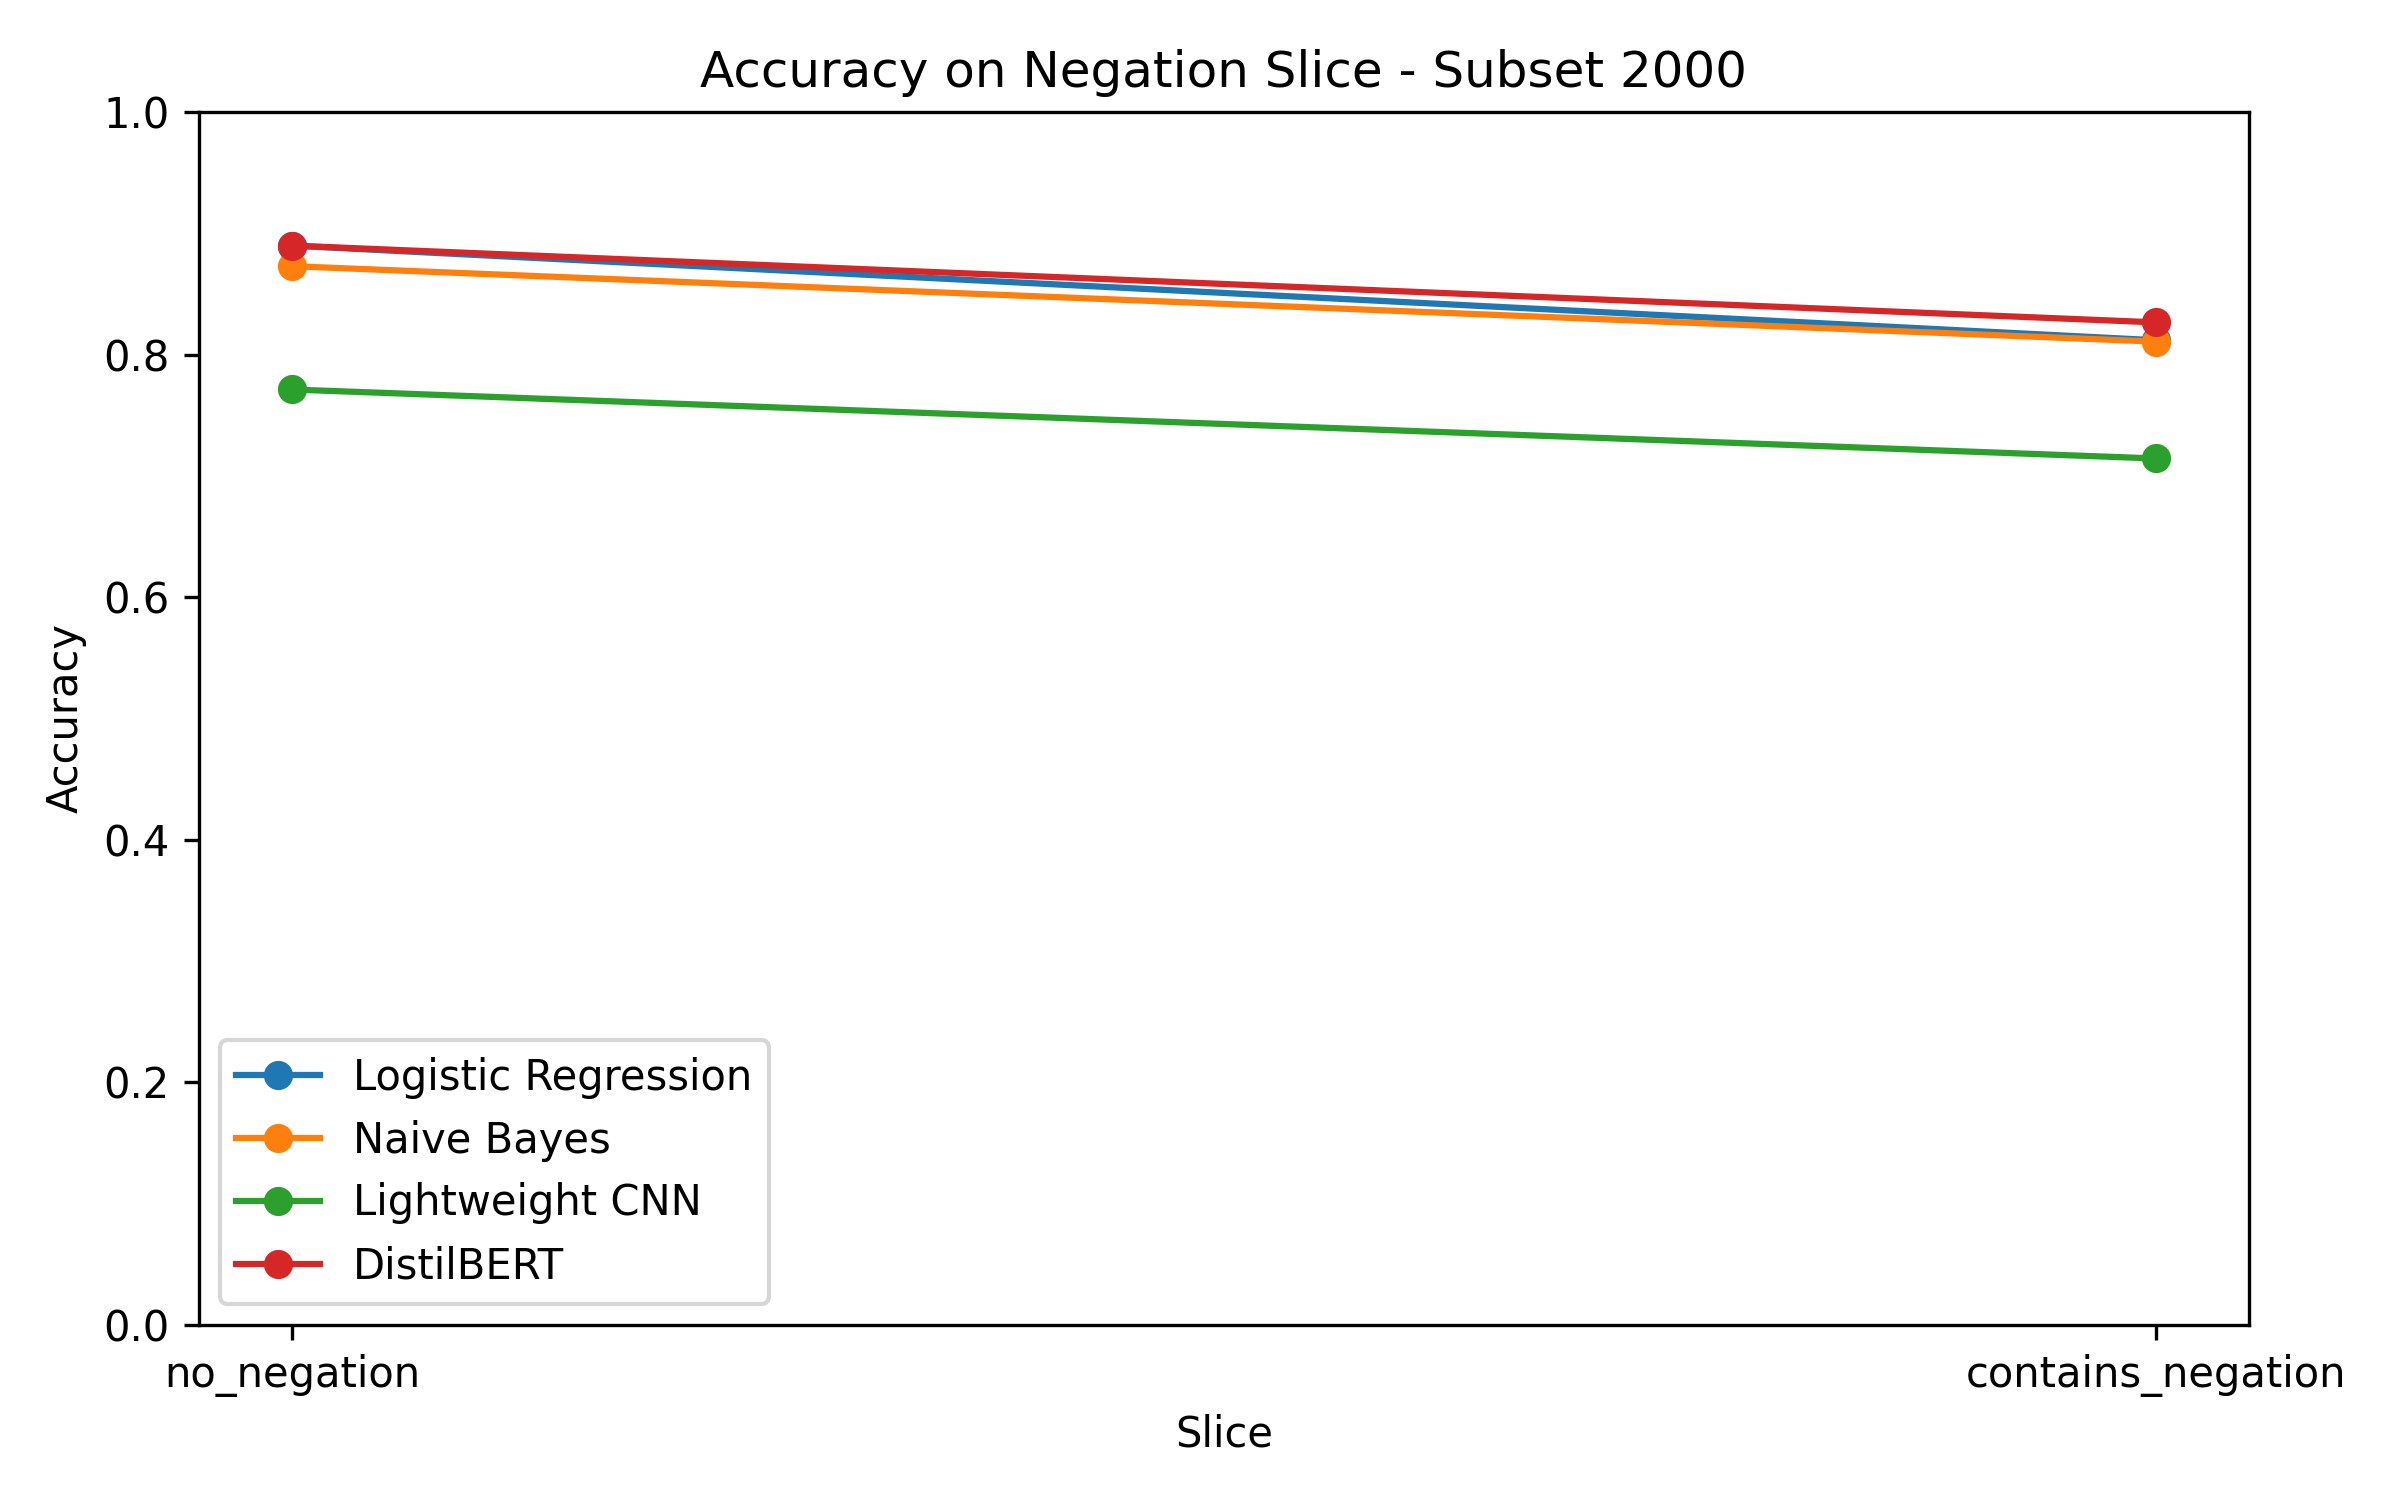

In [30]:
negation_results = pd.read_csv("../Results/negation_slice_results_subset_2000.csv")
display(negation_results)

display(Image("../figures/negation_slice_accuracy_subset_2000.png"))

## Negation Analysis

All models performed better on reviews without negation than on reviews containing negation. This is expected because negation makes sentiment classification more difficult.

DistilBERT achieved the best performance on the negation subset, which suggests that pretrained contextual representations help with more complex language patterns. The CNN had the lowest performance on this slice.

## Error Examples

The following table shows some examples that were incorrectly classified by the models. These examples are useful for understanding common failure cases.

In [31]:
error_examples = pd.read_csv("../Results/error_examples_subset_2000.csv")
display(error_examples.head(10))

,model,true_label,predicted_label,text
0,Logistic Regression,0,1,Not much to say other than plenty of Wire-fu a...
1,Logistic Regression,1,0,It could be easy to complain about the quality...
2,Logistic Regression,0,1,"Intended as light entertainment, this film is ..."
3,Logistic Regression,1,0,It's really too bad that nobody knows about th...
4,Logistic Regression,0,1,Unlike Terms of Endearment and Steel Magnolia'...
5,Logistic Regression,0,1,A very sensitive topic--15 y/o girl abandoned ...
6,Logistic Regression,1,0,"Late night on BBC1, was on my way to bed but c..."
7,Logistic Regression,0,1,A not so good action thriller because it unsuc...
8,Logistic Regression,0,1,This series takes a classic story and makes ru...
9,Logistic Regression,1,0,I'd like to point out these excellent points i...


## Error Analysis

Common error cases include mixed-sentiment reviews, long reviews with multiple opinions, and reviews where the sentiment depends on context rather than simple positive or negative words.

These examples show that sentiment classification is harder when the review contains sarcasm, contrast, negation, or both positive and negative comments in the same review.

## Conclusion

Under the same 2,000-example training setting, DistilBERT achieved the best test performance. This shows the benefit of pretrained transformer representations when labeled data is limited.

However, Logistic Regression and Naive Bayes were also strong baselines, showing that TF-IDF features are still effective for IMDb sentiment classification.

The Lightweight CNN performed lower because it was trained from scratch on a small dataset. The slice analysis showed that very long reviews and reviews containing negation were generally more difficult for the models.